# Retention-Intelligence-system — EDA

- Distribution of order values and quantities (looking for outliers)
- Purchase frequency per customer
- Time span covered and any seasonality
- The churn threshold (90 days) against the actual gap distribution between orders

In [1]:
# Importing the dependencies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'd:/DS Learning/retainiq/data/processed/transactions_clean.csv', parse_dates=['invoice_date'])
df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,line_total
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [2]:
# finding the last date in the dataset
observation_date = df["invoice_date"].max() + pd.Timedelta(days=1)
observation_date

Timestamp('2011-12-10 12:50:00')

In [ ]:
# doing some feature engineering here 

rfm = (
        df.groupby("customer_id")
        .agg(
            recency_days=("invoice_date", lambda x: (observation_date - x.max()).days),
            frequency=("invoice_no", "nunique"),
            monetary=("line_total", "sum"),
        )
        .reset_index()
    )
rfm

,customer_id,recency_days,frequency,monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40
...,...,...,...,...
5873,18283,4,22,2664.90
5874,18284,432,1,461.68
5875,18285,661,1,427.00
5876,18286,477,2,1296.43


In [18]:
rfm["avg_order_value"] = rfm["monetary"] / rfm["frequency"]
rfm

,customer_id,recency_days,frequency,monetary,avg_order_value
0,12346,326,12,77556.46,6463.038333
1,12347,2,8,4921.53,615.191250
2,12348,75,5,2019.40,403.880000
3,12349,19,4,4428.69,1107.172500
4,12350,310,1,334.40,334.400000
...,...,...,...,...,...
5873,18283,4,22,2664.90,121.131818
5874,18284,432,1,461.68,461.680000
5875,18285,661,1,427.00,427.000000
5876,18286,477,2,1296.43,648.215000


In [ ]:
# choosing 1.5 as arbitary value as customer will spend 50% of his previous total spend
rfm["estimated_clv"] = rfm["avg_order_value"] * rfm["frequency"] * 1.5
rfm

,customer_id,recency_days,frequency,monetary,avg_order_value,estimated_clv
0,12346,326,12,77556.46,6463.038333,116334.690
1,12347,2,8,4921.53,615.191250,7382.295
2,12348,75,5,2019.40,403.880000,3029.100
3,12349,19,4,4428.69,1107.172500,6643.035
4,12350,310,1,334.40,334.400000,501.600
...,...,...,...,...,...,...
5873,18283,4,22,2664.90,121.131818,3997.350
5874,18284,432,1,461.68,461.680000,692.520
5875,18285,661,1,427.00,427.000000,640.500
5876,18286,477,2,1296.43,648.215000,1944.645


In [ ]:
# This method genarates the entire EDA into a html file with interactive options

import pandas as pd
from ydata_profiling import ProfileReport

df = pd.read_csv(r'd:/DS Learning/retainiq/data/processed/transactions_clean.csv', parse_dates=['invoice_date'])
# Generate the profile report
profile = ProfileReport(df, title="transactions")
# Display the report in a Jupyter Notebook
profile.to_notebook_iframe()
# Save the report as an HTML file
profile.to_file("books_data.html")

In [2]:
df.describe(include='all')

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,line_total
count,779425.000000,779425,779425,779425.000000,779425,779425.000000,779425.000000,779425,779425.000000
unique,NaN,4631,5283,NaN,NaN,NaN,NaN,41,NaN
top,NaN,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom,NaN
freq,NaN,5023,5016,NaN,NaN,NaN,NaN,700388,NaN
mean,537426.828586,NaN,NaN,13.489370,2011-01-03 01:44:42.593475584,3.218488,15320.360461,NaN,22.291823
min,489434.000000,NaN,NaN,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,NaN,0.001000
25%,514483.000000,NaN,NaN,2.000000,2010-07-02 14:39:00,1.250000,13971.000000,NaN,4.950000
50%,536754.000000,NaN,NaN,6.000000,2010-12-02 14:09:00,1.950000,15247.000000,NaN,12.480000
75%,561995.000000,NaN,NaN,12.000000,2011-08-01 13:44:00,3.750000,16794.000000,NaN,19.800000
max,581587.000000,NaN,NaN,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,NaN,168469.600000


In [3]:
df.isnull().sum()

invoice_no      0
stock_code      0
description     0
quantity        0
invoice_date    0
unit_price      0
customer_id     0
country         0
line_total      0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice_no    779425 non-null  int64         
 1   stock_code    779425 non-null  object        
 2   description   779425 non-null  object        
 3   quantity      779425 non-null  int64         
 4   invoice_date  779425 non-null  datetime64[ns]
 5   unit_price    779425 non-null  float64       
 6   customer_id   779425 non-null  int64         
 7   country       779425 non-null  object        
 8   line_total    779425 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 53.5+ MB


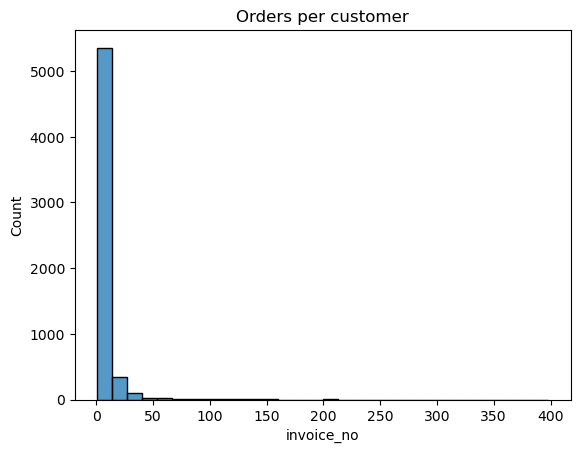

In [11]:
orders_per_customer = df.groupby('customer_id')['invoice_no'].nunique()
# print(orders_per_customer)
sns.histplot(orders_per_customer, bins=30)
plt.title('Orders per customer')
plt.show()

*the upper chart shows that how many order did customers made*

customer_id        
12346        20962      0.0
             20963      0.0
             27601      3.0
             27612      0.0
             30272     16.0
                       ... 
18287        668132     0.0
             668125     0.0
             693383    15.0
             693381     0.0
             693382     0.0
Name: invoice_date, Length: 773547, dtype: float64


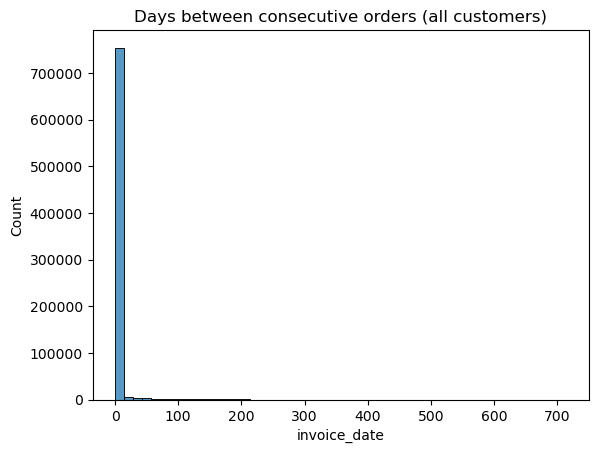

In [14]:
# Gap between consecutive orders per customer — helps sanity-check the churn window
gaps = (
    df.sort_values('invoice_date')
      .groupby('customer_id')['invoice_date']
      .apply(lambda x: x.diff().dt.days.dropna())
)
print(gaps)
sns.histplot(gaps, bins=50)
plt.title('Days between consecutive orders (all customers)')
plt.show()

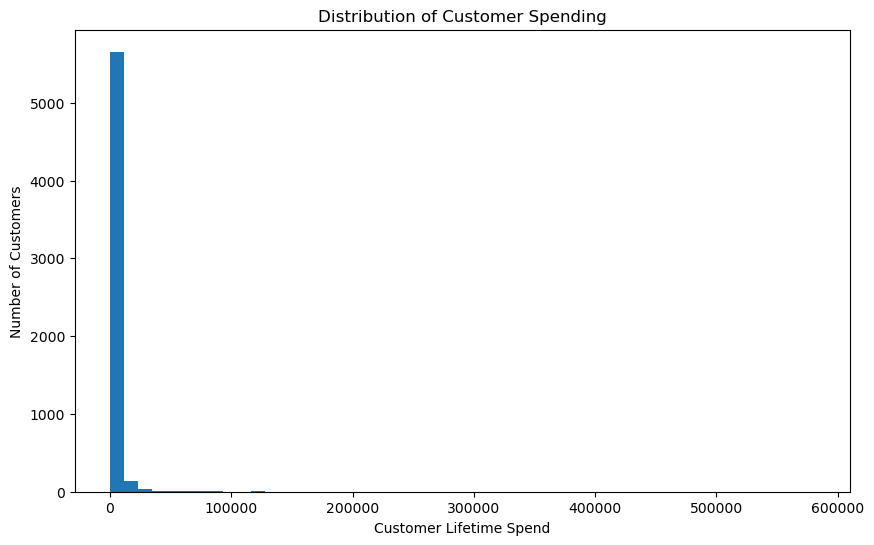

In [ ]:
# Total spend customer has made

import pandas as pd
import matplotlib.pyplot as plt

# Total spend per customer
customer_spend = (
    df.groupby("customer_id")["line_total"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(10,6))

plt.hist(customer_spend["line_total"], bins=50)

plt.xlabel("Customer Lifetime Spend")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Spending")

plt.show()

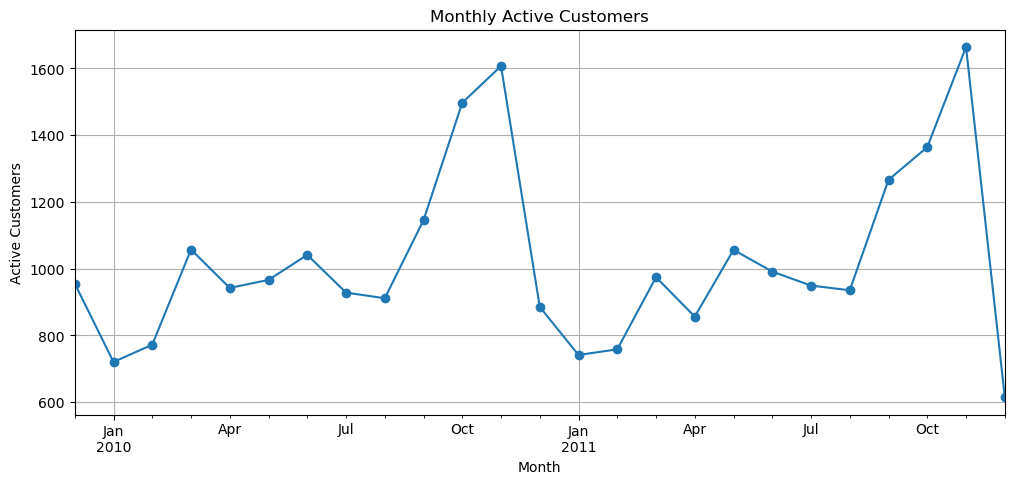

In [ ]:
# Monthly active customers for seasonality-trends
active = (
    df.groupby(df["invoice_date"].dt.to_period("M"))["customer_id"]
      .nunique()
)

plt.figure(figsize=(12,5))

active.plot(marker="o")

plt.title("Monthly Active Customers")

plt.xlabel("Month")

plt.ylabel("Active Customers")

plt.grid(True)

plt.show()